In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_theme(style='whitegrid')

df = pd.read_csv(
    r"C:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\data\raw\Sri_Lanka_NASA_POWER_Weather_2000_2025.csv"
)

print(df.shape)
df.head()

(237425, 11)


,date,district,latitude,longitude,temperature_avg_c,temperature_max_c,temperature_min_c,rainfall_mm,humidity_percent,solar_radiation_mj_m2_day,wind_speed_m_s
0,2000-01-01,Ampara,7.2917,81.672,25.49,26.65,24.50,0.02,77.67,16.30,6.55
1,2000-01-02,Ampara,7.2917,81.672,25.61,26.47,24.96,0.04,88.04,10.51,7.15
2,2000-01-03,Ampara,7.2917,81.672,25.76,26.46,25.26,0.02,87.67,4.25,6.80
3,2000-01-04,Ampara,7.2917,81.672,25.45,26.16,25.06,0.01,88.50,12.88,6.98
4,2000-01-05,Ampara,7.2917,81.672,25.81,26.66,25.12,0.07,88.59,11.23,6.26


In [2]:
df.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 237425 entries, 0 to 237424
Data columns (total 11 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   date                       237425 non-null  object 
 1   district                   237425 non-null  object 
 2   latitude                   237425 non-null  float64
 3   longitude                  237425 non-null  float64
 4   temperature_avg_c          237425 non-null  float64
 5   temperature_max_c          237425 non-null  float64
 6   temperature_min_c          237425 non-null  float64
 7   rainfall_mm                237425 non-null  float64
 8   humidity_percent           237425 non-null  float64
 9   solar_radiation_mj_m2_day  237425 non-null  float64
 10  wind_speed_m_s             237425 non-null  float64
dtypes: float64(9), object(2)
memory usage: 46.3 MB


In [3]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
latitude,237425.0,7.586436,1.034769,5.9549,6.9271,7.2917,8.3114,9.6615
longitude,237425.0,80.588560,0.532950,79.8283,80.2168,80.4971,81.0188,81.6747
temperature_avg_c,237425.0,26.558000,1.934465,17.2700,25.4000,26.6800,27.9300,32.7500
temperature_max_c,237425.0,29.585956,2.219842,21.2700,28.0400,29.2200,30.9400,41.5000
temperature_min_c,237425.0,24.319077,2.520346,10.6000,22.6200,24.8400,26.2800,30.5500
rainfall_mm,237425.0,4.752410,8.639944,0.0000,0.1900,1.4800,5.8000,294.2200
humidity_percent,237425.0,81.090404,6.802399,48.9400,76.6000,81.8800,86.2300,97.5600
solar_radiation_mj_m2_day,237425.0,19.198766,4.283449,1.0400,16.9900,20.0500,22.3400,27.6300
wind_speed_m_s,237425.0,4.636669,2.018254,0.3200,3.0400,4.4700,6.0500,15.0400


### Data quality checks

In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nFully duplicated rows:", df.duplicated().sum())
print("Duplicated (date, district) pairs:", df.duplicated(subset=['date', 'district']).sum())

Missing values per column:
date                         0
district                     0
latitude                     0
longitude                    0
temperature_avg_c            0
temperature_max_c            0
temperature_min_c            0
rainfall_mm                  0
humidity_percent             0
solar_radiation_mj_m2_day    0
wind_speed_m_s               0
dtype: int64

Fully duplicated rows: 0
Duplicated (date, district) pairs: 0


### Date coverage completeness (per district)

In [5]:
# Make sure date column is datetime
df['date'] = pd.to_datetime(df['date'])

# Create the complete expected daily date range
expected_days = pd.date_range(
    df['date'].min(),
    df['date'].max(),
    freq='D'
)

# Display overall date range
print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Expected days in range: {len(expected_days)}")

# Count unique recorded days for each district
coverage = df.groupby('district')['date'].nunique()

print("\nDays recorded per district (should all match expected days):")
print(coverage)

# Identify districts that have missing dates
missing_districts = coverage[
    coverage != len(expected_days)
].index.tolist()

print("\nDistricts with missing days:")
print(missing_districts)

Date range: 2000-01-01 to 2025-12-31
Expected days in range: 9497

Days recorded per district (should all match expected days):
district
Ampara          9497
Anuradhapura    9497
Badulla         9497
Batticaloa      9497
Colombo         9497
Galle           9497
Gampaha         9497
Hambantota      9497
Jaffna          9497
Kalutara        9497
Kandy           9497
Kegalle         9497
Kilinochchi     9497
Kurunegala      9497
Mannar          9497
Matale          9497
Matara          9497
Monaragala      9497
Mullaitivu      9497
Nuwara Eliya    9497
Polonnaruwa     9497
Puttalam        9497
Ratnapura       9497
Trincomalee     9497
Vavuniya        9497
Name: date, dtype: int64

Districts with missing days:
[]


### Geographic consistency (lat/long per district)

In [6]:
geo_check = df.groupby('district')[['latitude', 'longitude']].nunique()
print("Unique lat/long values per district (should be 1 each - fixed station per district):")
print(geo_check[(geo_check['latitude'] > 1) | (geo_check['longitude'] > 1)])
print("All districts have a single fixed coordinate:",
      (geo_check['latitude'] == 1).all() and (geo_check['longitude'] == 1).all())

Unique lat/long values per district (should be 1 each - fixed station per district):
Empty DataFrame
Columns: [latitude, longitude]
Index: []
All districts have a single fixed coordinate: True


### Distribution of each weather variable

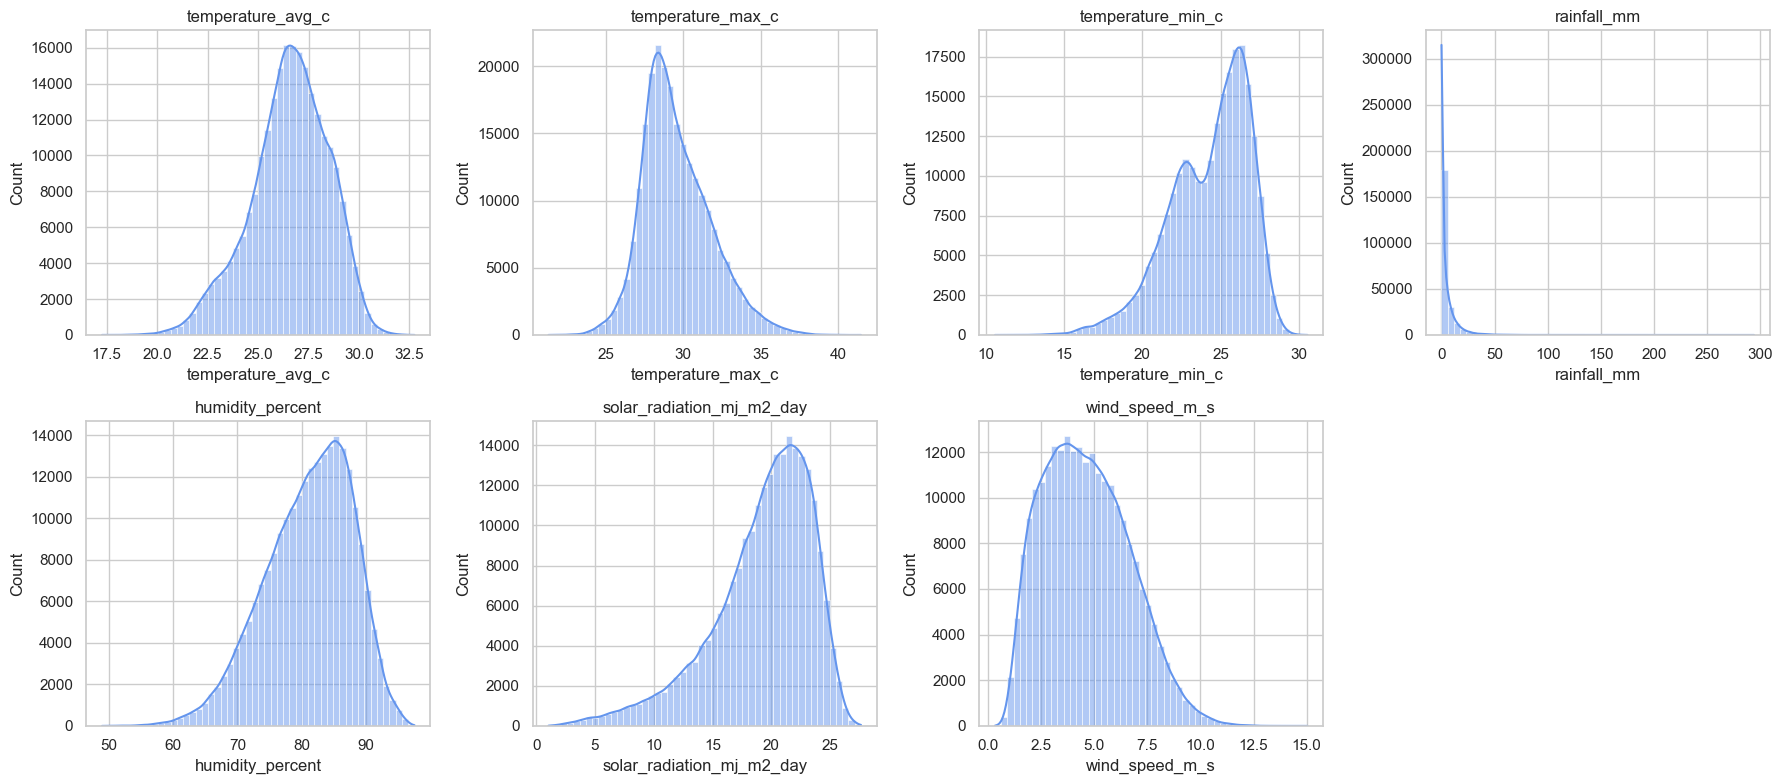

In [7]:
import os

# Create output folder if it does not exist
OUTPUT_DIR = r'C:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\outputs\notebooks_task2'
os.makedirs(OUTPUT_DIR, exist_ok=True)

num_cols = ['temperature_avg_c', 'temperature_max_c', 'temperature_min_c',
            'rainfall_mm', 'humidity_percent', 'solar_radiation_mj_m2_day', 'wind_speed_m_s']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))
axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(df[col], kde=True, ax=axes[i], color='cornflowerblue', bins=50)
    axes[i].set_title(col)
axes[-1].axis('off')
plt.tight_layout()

# Save graph
plt.savefig(
    os.path.join(OUTPUT_DIR, '16_weather_variable_distributions.png'),
    dpi=120,
    bbox_inches='tight'
)

plt.show()

### Physical consistency checks

In [8]:
# temperature_min should never exceed temperature_max, and avg should sit between them
bad_temp_order = df[df['temperature_min_c'] > df['temperature_max_c']]
bad_avg = df[(df['temperature_avg_c'] < df['temperature_min_c']) |
             (df['temperature_avg_c'] > df['temperature_max_c'])]

print(f"Rows where min temp > max temp: {len(bad_temp_order)}")
print(f"Rows where avg temp falls outside [min, max]: {len(bad_avg)}")

print(f"\nNegative rainfall values: {(df['rainfall_mm'] < 0).sum()}")
print(f"Humidity outside [0, 100]%: {((df['humidity_percent'] < 0) | (df['humidity_percent'] > 100)).sum()}")
print(f"Negative wind speed: {(df['wind_speed_m_s'] < 0).sum()}")
print(f"Negative solar radiation: {(df['solar_radiation_mj_m2_day'] < 0).sum()}")

Rows where min temp > max temp: 0
Rows where avg temp falls outside [min, max]: 0

Negative rainfall values: 0
Humidity outside [0, 100]%: 0
Negative wind speed: 0
Negative solar radiation: 0


### Outlier detection (IQR method)

In [9]:
def iqr_outlier_summary(data, cols):
    rows = []
    for col in cols:
        q1, q3 = data[col].quantile([0.25, 0.75])
        iqr = q3 - q1
        lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
        n_out = ((data[col] < lower) | (data[col] > upper)).sum()
        rows.append({'feature': col, 'lower_bound': round(lower, 2),
                     'upper_bound': round(upper, 2), 'n_outliers': n_out,
                     'pct_outliers': round(100 * n_out / len(data), 2)})
    return pd.DataFrame(rows)

iqr_outlier_summary(df, num_cols)

,feature,lower_bound,upper_bound,n_outliers,pct_outliers
0,temperature_avg_c,21.60,31.73,2492,1.05
1,temperature_max_c,23.69,35.29,3791,1.60
2,temperature_min_c,17.13,31.77,2220,0.94
3,rainfall_mm,-8.22,14.21,21215,8.94
4,humidity_percent,62.15,100.68,1628,0.69
5,solar_radiation_mj_m2_day,8.96,30.37,7294,3.07
6,wind_speed_m_s,-1.47,10.56,676,0.28


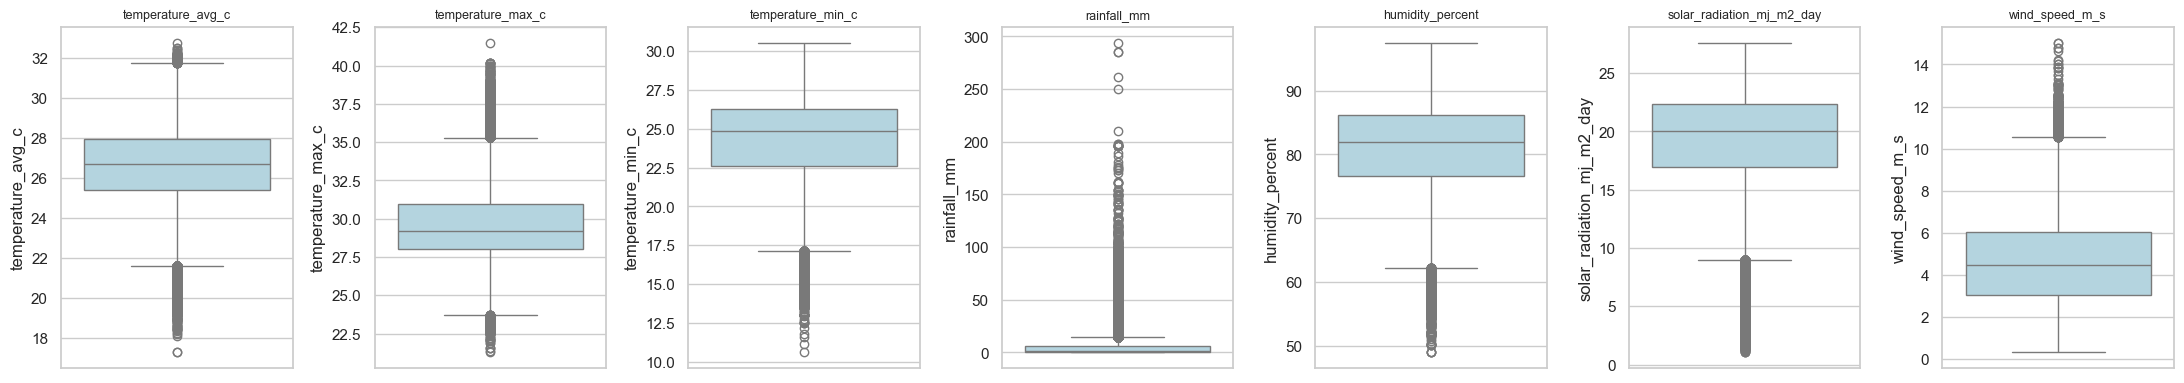

In [10]:
fig, axes = plt.subplots(1, len(num_cols), figsize=(22, 4))
for i, col in enumerate(num_cols):
    sns.boxplot(y=df[col], ax=axes[i], color='lightblue')
    axes[i].set_title(col, fontsize=9)
plt.tight_layout()

# Save graph
plt.savefig(
    os.path.join(OUTPUT_DIR, '17_weather_variable_boxplots.png'),
    dpi=120,
    bbox_inches='tight'
)

plt.show()

### Correlation between weather variables

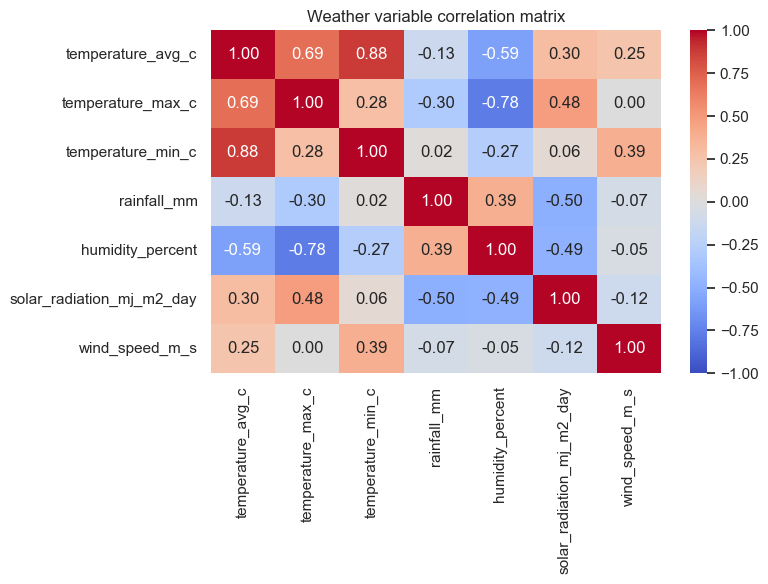

In [11]:
corr = df[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Weather variable correlation matrix')
plt.tight_layout()

# Save graph
plt.savefig(
    os.path.join(OUTPUT_DIR, '18_weather_variable_correlation.png'),
    dpi=120,
    bbox_inches='tight'
)

plt.show()

### Time feature engineering

In [13]:
df['year'] = df['date'].dt.year
df['month'] = df['date'].dt.month
df['day_of_year'] = df['date'].dt.dayofyear

def assign_season(month):
    return 'Maha' if month in [9, 10, 11, 12, 1, 2, 3] else 'Yala'

df['season'] = df['month'].apply(assign_season)
df[['date', 'month', 'season']].drop_duplicates(subset='month').sort_values('month')

,date,month,season
0,2000-01-01,1,Maha
31,2000-02-01,2,Maha
60,2000-03-01,3,Maha
91,2000-04-01,4,Yala
121,2000-05-01,5,Yala
152,2000-06-01,6,Yala
182,2000-07-01,7,Yala
213,2000-08-01,8,Yala
244,2000-09-01,9,Maha
274,2000-10-01,10,Maha


### Seasonal / annual patterns

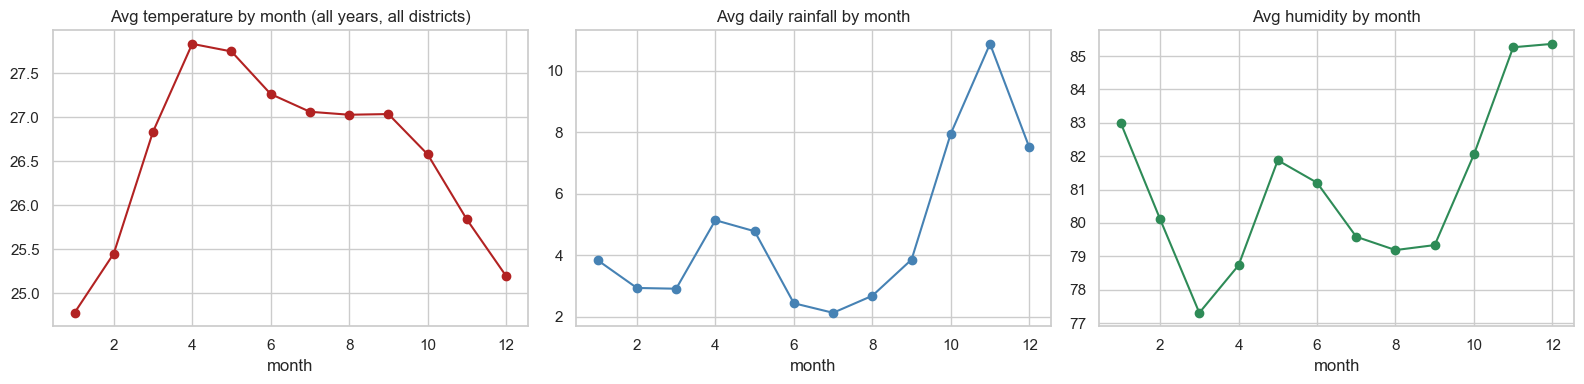

In [14]:
monthly = df.groupby('month')[['temperature_avg_c', 'rainfall_mm', 'humidity_percent']].mean()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
monthly['temperature_avg_c'].plot(kind='line', marker='o', ax=axes[0], color='firebrick')
axes[0].set_title('Avg temperature by month (all years, all districts)')
monthly['rainfall_mm'].plot(kind='line', marker='o', ax=axes[1], color='steelblue')
axes[1].set_title('Avg daily rainfall by month')
monthly['humidity_percent'].plot(kind='line', marker='o', ax=axes[2], color='seagreen')
axes[2].set_title('Avg humidity by month')
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, '19_monthly_weather_patterns.png'),
    dpi=120,
    bbox_inches='tight'
)

plt.show()

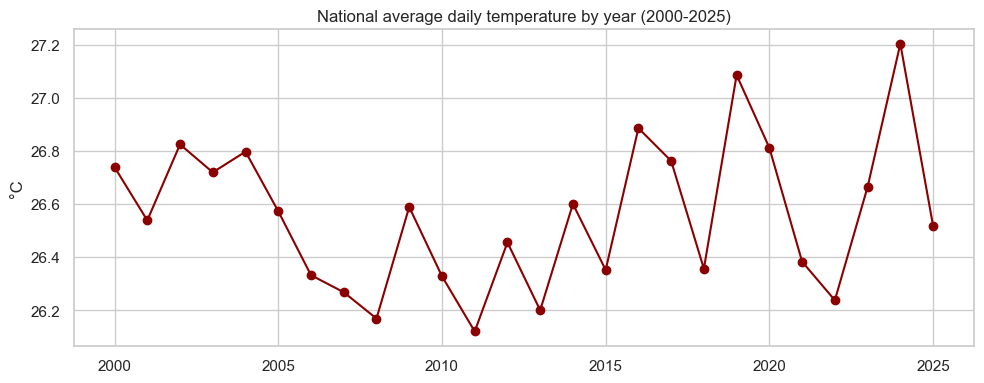

In [15]:
yearly_national = df.groupby('year')[['temperature_avg_c', 'rainfall_mm']].mean()
plt.figure(figsize=(10, 4))
plt.plot(yearly_national.index, yearly_national['temperature_avg_c'], marker='o', color='darkred')
plt.title('National average daily temperature by year (2000-2025)')
plt.ylabel('°C')
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, '20_yearly_weather_patterns.png'),
    dpi=120,
    bbox_inches='tight'
)

plt.show()

### District-level comparison

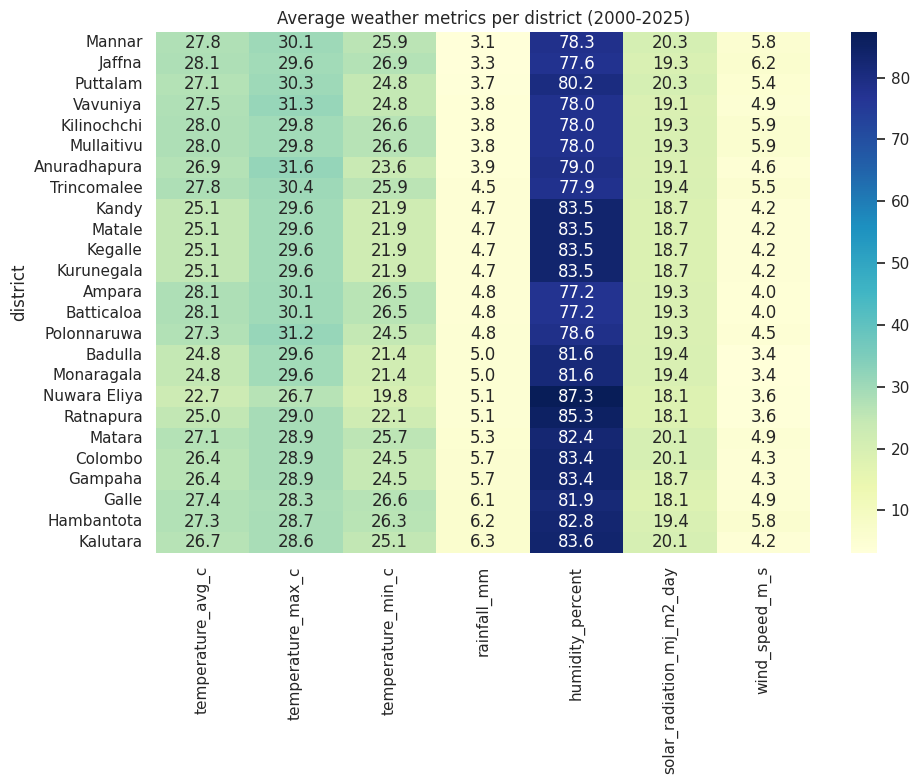

In [ ]:
district_avg = df.groupby('district')[num_cols].mean().round(2).sort_values('rainfall_mm')
plt.figure(figsize=(10, 8))
sns.heatmap(district_avg, annot=True, fmt='.1f', cmap='YlGnBu')
plt.title('Average weather metrics per district (2000-2025)')
plt.tight_layout()

plt.savefig(
    os.path.join(OUTPUT_DIR, '20_yearly_weather_patterns.png'),
    dpi=120,
    bbox_inches='tight'
)

plt.show()

### Downcasting for memory efficiency

In [16]:
mem_before = df.memory_usage(deep=True).sum() / 1e6
print(f"Memory before downcasting: {mem_before:.1f} MB")

float_cols = df.select_dtypes(include='float64').columns
df[float_cols] = df[float_cols].apply(pd.to_numeric, downcast='float')

int_cols = df.select_dtypes(include='int64').columns
df[int_cols] = df[int_cols].apply(pd.to_numeric, downcast='integer')

df['district'] = df['district'].astype('category')
df['season'] = df['season'].astype('category')

mem_after = df.memory_usage(deep=True).sum() / 1e6
print(f"Memory after downcasting:  {mem_after:.1f} MB")
print(f"Reduction: {100 * (1 - mem_after / mem_before):.1f}%")

Memory before downcasting: 51.8 MB
Memory after downcasting:  13.8 MB
Reduction: 73.4%


### Aggregation to monthly and seasonal granularity

In [19]:
expected_days = pd.date_range(
    df['date'].min(),
    df['date'].max(),
    freq='D'
)

print(f"Date range: {df['date'].min().date()} to {df['date'].max().date()}")
print(f"Expected days in range: {len(expected_days)}")

coverage = df.groupby('district')['date'].nunique()

print("\nDays recorded per district:")
print(coverage)

missing_districts = coverage[
    coverage != len(expected_days)
].index.tolist()

print("\nDistricts with missing days:")
print(missing_districts)

Date range: 2000-01-01 to 2025-12-31
Expected days in range: 9497

Days recorded per district:
district
Ampara          9497
Anuradhapura    9497
Badulla         9497
Batticaloa      9497
Colombo         9497
Galle           9497
Gampaha         9497
Hambantota      9497
Jaffna          9497
Kalutara        9497
Kandy           9497
Kegalle         9497
Kilinochchi     9497
Kurunegala      9497
Mannar          9497
Matale          9497
Matara          9497
Monaragala      9497
Mullaitivu      9497
Nuwara Eliya    9497
Polonnaruwa     9497
Puttalam        9497
Ratnapura       9497
Trincomalee     9497
Vavuniya        9497
Name: date, dtype: int64

Districts with missing days:
[]


C:\Users\kalua\AppData\Local\Temp\ipykernel_15152\4208153482.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  coverage = df.groupby('district')['date'].nunique()


In [20]:
seasonal_agg = (
    df.groupby(['district', 'year', 'season'])
    .agg(
        temperature_avg_c=('temperature_avg_c', 'mean'),
        temperature_max_c=('temperature_max_c', 'max'),
        temperature_min_c=('temperature_min_c', 'min'),
        rainfall_mm_total=('rainfall_mm', 'sum'),
        humidity_percent=('humidity_percent', 'mean'),
        solar_radiation_mj_m2_day=('solar_radiation_mj_m2_day', 'mean'),
        wind_speed_m_s=('wind_speed_m_s', 'mean')
    )
    .reset_index()
)

seasonal_agg.head()

C:\Users\kalua\AppData\Local\Temp\ipykernel_15152\295167549.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['district', 'year', 'season'])


,district,year,season,temperature_avg_c,temperature_max_c,temperature_min_c,rainfall_mm_total,humidity_percent,solar_radiation_mj_m2_day,wind_speed_m_s
0,Ampara,2000,Maha,27.293472,34.160000,23.65,706.929993,77.859772,17.383333,4.338263
1,Ampara,2000,Yala,29.430916,36.520000,25.60,290.279999,69.238037,21.324444,4.026275
2,Ampara,2001,Maha,27.185848,35.220001,22.07,901.010010,78.109154,18.786463,3.910990
3,Ampara,2001,Yala,29.303921,34.689999,25.35,369.250000,71.558624,21.286144,3.736209
4,Ampara,2002,Maha,27.411179,35.470001,23.33,955.169983,78.288734,18.130896,4.147264


### Save processed outputs

In [21]:
monthly_agg = (
    df.groupby(['district', 'year', 'month'])
    .agg(
        temperature_avg_c=('temperature_avg_c', 'mean'),
        temperature_max_c=('temperature_max_c', 'max'),
        temperature_min_c=('temperature_min_c', 'min'),
        rainfall_mm_total=('rainfall_mm', 'sum'),
        humidity_percent=('humidity_percent', 'mean'),
        solar_radiation_mj_m2_day=('solar_radiation_mj_m2_day', 'mean'),
        wind_speed_m_s=('wind_speed_m_s', 'mean')
    )
    .reset_index()
)

monthly_agg.head()

C:\Users\kalua\AppData\Local\Temp\ipykernel_15152\1226511304.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(['district', 'year', 'month'])


,district,year,month,temperature_avg_c,temperature_max_c,temperature_min_c,rainfall_mm_total,humidity_percent,solar_radiation_mj_m2_day,wind_speed_m_s
0,Ampara,2000,1,26.015160,28.559999,23.650000,30.010000,81.665802,15.386129,5.802581
1,Ampara,2000,2,26.651726,29.620001,24.570000,81.970001,79.834480,18.453449,4.135172
2,Ampara,2000,3,27.780968,31.400000,25.100000,29.900000,75.979355,20.471613,3.633226
3,Ampara,2000,4,29.377001,34.750000,26.240000,62.130001,72.113327,22.487000,2.722667
4,Ampara,2000,5,30.449354,36.520000,27.139999,34.799999,67.864197,22.146774,3.198065


In [22]:
district_avg = (
    df.groupby('district')
    .agg(
        temperature_avg_c=('temperature_avg_c', 'mean'),
        temperature_max_c=('temperature_max_c', 'mean'),
        temperature_min_c=('temperature_min_c', 'mean'),
        rainfall_mm=('rainfall_mm', 'mean'),
        humidity_percent=('humidity_percent', 'mean'),
        solar_radiation_mj_m2_day=('solar_radiation_mj_m2_day', 'mean'),
        wind_speed_m_s=('wind_speed_m_s', 'mean')
    )
)

district_avg.head()

C:\Users\kalua\AppData\Local\Temp\ipykernel_15152\3578755204.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('district')


,temperature_avg_c,temperature_max_c,temperature_min_c,rainfall_mm,humidity_percent,solar_radiation_mj_m2_day,wind_speed_m_s
district,,,,,,,
Ampara,28.065008,30.109524,26.463215,4.748876,77.191330,19.255491,3.985890
Anuradhapura,26.864479,31.631357,23.551394,3.901270,79.023407,19.058195,4.591566
Badulla,24.843206,29.567419,21.446867,5.014384,81.624474,19.417048,3.429148
Batticaloa,28.065008,30.109524,26.463215,4.748876,77.191330,19.255491,3.985890
Colombo,26.434534,28.906786,24.483046,5.697343,83.403328,20.084682,4.321682


In [23]:
import os

OUTPUT_DIR = r'C:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\data\processed\weather_data'

os.makedirs(OUTPUT_DIR, exist_ok=True)

df.to_csv(
    os.path.join(OUTPUT_DIR, 'weather_daily_clean.csv'),
    index=False
)

monthly_agg.to_csv(
    os.path.join(OUTPUT_DIR, 'weather_monthly_by_district.csv'),
    index=False
)

seasonal_agg.to_csv(
    os.path.join(OUTPUT_DIR, 'weather_seasonal_by_district.csv'),
    index=False
)

district_avg.to_csv(
    os.path.join(OUTPUT_DIR, 'weather_district_climatology.csv')
)

print("Saved files:")

for f in sorted(os.listdir(OUTPUT_DIR)):
    if f.startswith('weather'):
        print(' -', f)

print("\nSaved successfully to:")
print(OUTPUT_DIR)

Saved files:
 - weather_daily_clean.csv
 - weather_district_climatology.csv
 - weather_monthly_by_district.csv
 - weather_seasonal_by_district.csv

Saved successfully to:
C:\Projects\SmartCrop-An-ANN-seasonal-crop-recommendation-system\data\processed\weather_data
